# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [13]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [14]:
df = pd.read_csv(r"D:\Навчання\Data Analytics\КУРС DATA ANALIST\python\ДЗ\Machine_learning\credit_risk_dataset.csv")

print(f"Розмір датасету: {df.shape}")

Розмір датасету: (32581, 12)


In [15]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [18]:
# Розподіл цільової змінної (loan_status)
loan_status_counts = df['loan_status'].value_counts()
loan_status_percent = df['loan_status'].value_counts(normalize=True) * 100

print("Кількість записів по класах:")
print(loan_status_counts)
print("\nВідсотковий розподіл:")
print(loan_status_percent)

Кількість записів по класах:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Відсотковий розподіл:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


Цільова змінна loan_status є незбалансованою: 78% спостережень відповідають класу "сплачено" (0), і лише 22% — класу "дефолт" (1). Це означає, що при побудові моделі варто врахувати дисбаланс класів.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [21]:
# Перевірка пропущених значень
missing = df.isnull().sum()
missing = missing[missing > 0]

# Формуємо таблицю з кількістю і відсотком пропусків
missing_df = pd.DataFrame({
    'Кількість пропусків': missing,
    'Відсоток (%)': (missing / len(df) * 100).round(2)
})

print(missing_df)


                   Кількість пропусків  Відсоток (%)
person_emp_length                  895          2.75
loan_int_rate                     3116          9.56


In [22]:
# Заповнюємо пропуски медіаною для числових колонок
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

# Перевіряємо ще раз
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_10036\3532358333.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10036\3532358333.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [23]:
# Статистика по числовим змінним
df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Text(0.5, 1.0, 'person_income - До обробки викидів')

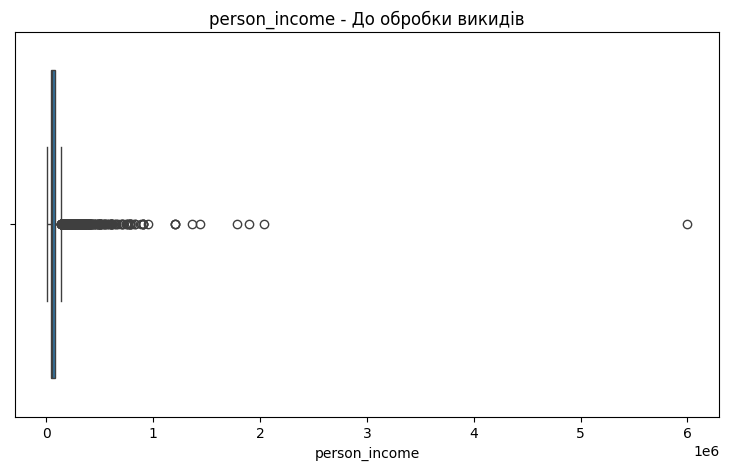

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['person_income'])
plt.title('person_income - До обробки викидів')


In [39]:
# 1. Вибираємо колонку
income = df['person_income']

# 2. Розраховуємо квартилі
Q1 = income.quantile(0.25)
Q3 = income.quantile(0.75)
IQR = Q3 - Q1

# 3. Визначаємо межі для викидів
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Нижня межа: {lower_bound:.2f}, Верхня межа: {upper_bound:.2f}")

# 4. Фільтруємо або обмежуємо значення
# Варіант 1: видалити викиди
df_no_outliers = df[(income >= lower_bound) & (income <= upper_bound)]

print(f"Розмір датасету до видалення викидів: {df.shape}")
print(f"Розмір після видалення викидів: {df_no_outliers.shape}")

Нижня межа: -22550.00, Верхня межа: 140250.00
Розмір датасету до видалення викидів: (32581, 12)
Розмір після видалення викидів: (31097, 12)


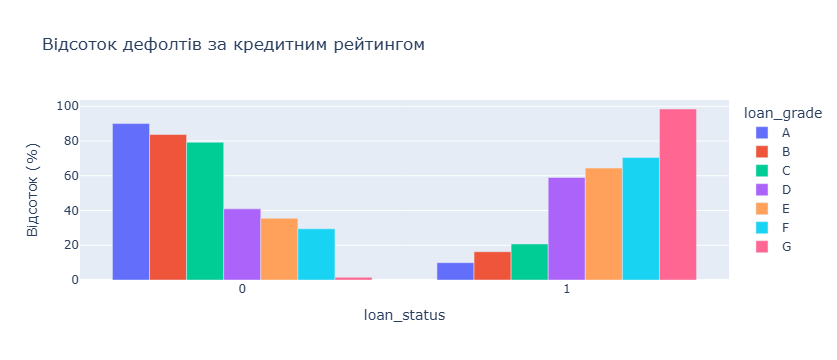

In [38]:
# Відсоток дефолтів по кредитному рейтингу
grade_default = df.groupby(['loan_grade', 'loan_status']).size().unstack()
grade_default_pct = grade_default.div(grade_default.sum(axis=1), axis=0) * 100

fig = px.bar(
    grade_default_pct.T,  # Транспонуємо, щоб краще читалося
    title='Відсоток дефолтів за кредитним рейтингом',
    labels={'value': 'Відсоток (%)', 'index': 'Loan Status'},
    barmode='group'
)
fig.show()


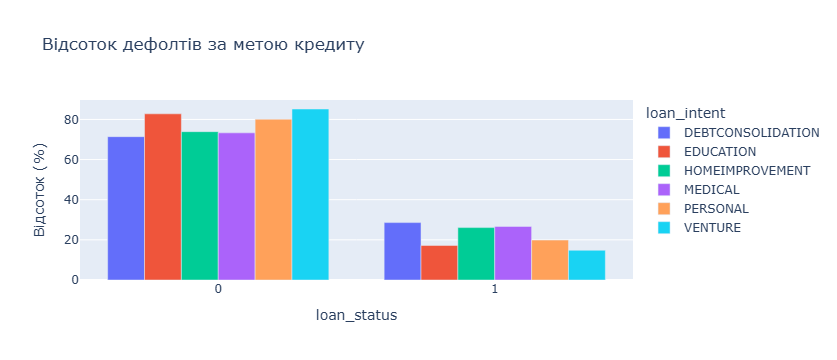

In [37]:
# Відсоток дефолтів по меті кредиту
intent_default = df.groupby(['loan_intent', 'loan_status']).size().unstack()
intent_default_pct = intent_default.div(intent_default.sum(axis=1), axis=0) * 100

fig = px.bar(
    intent_default_pct.T,  # Транспонуємо для кращого відображення
    title='Відсоток дефолтів за метою кредиту',
    labels={'value': 'Відсоток (%)', 'index': 'Статус кредиту'},
    barmode='group'
)
fig.show()



---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [48]:
# Матриця кореляцій для числових змінних
numeric_df = df_no_outliers[['person_age', 'person_income', 'person_emp_length', 
                       'loan_amnt', 'loan_int_rate','loan_percent_income']]
correlation_matrix = numeric_df.corr()

print("Матриця кореляцій:")
display(correlation_matrix)

Матриця кореляцій:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
person_age,1.000000,0.081485,0.155934,0.036407,0.009655,-0.023383
person_income,0.081485,1.000000,0.188611,0.385604,-0.034314,-0.329516
person_emp_length,0.155934,0.188611,1.000000,0.103383,-0.056518,-0.041463
loan_amnt,0.036407,0.385604,0.103383,1.000000,0.130542,0.642413
loan_int_rate,0.009655,-0.034314,-0.056518,0.130542,1.000000,0.119758
loan_percent_income,-0.023383,-0.329516,-0.041463,0.642413,0.119758,1.000000


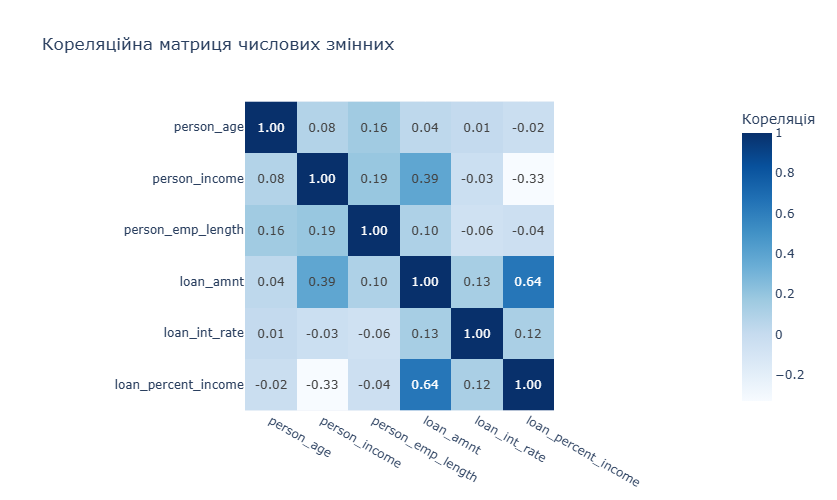

In [49]:
# Візуалізація heatmap
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='Blues',
    title='Кореляційна матриця числових змінних',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [50]:
# Визначаємо категоріальні змінні
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [53]:
# Фінальний набор ознак:
X = df_encoded.drop(columns=['loan_status'])  # всі ознаки, окрім цільової
y = df_encoded['loan_status']                  # цільова змінна

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 22
Розмір вибірки: 32581



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [55]:
# Розділяємо дані на навчальну та тестову вибірки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # зберігаємо пропорції класів
)

print(f"Train: {X_train.shape[0]} клієнтів")
print(f"Test: {X_test.shape[0]} клієнтів")
print(f"Відсоток дефолтів в train: {y_train.mean():.1%}")
print(f"Відсоток дефолтів в test: {y_test.mean():.1%}")

Train: 26064 клієнтів
Test: 6517 клієнтів
Відсоток дефолтів в train: 21.8%
Відсоток дефолтів в test: 21.8%


In [56]:
# Масштабування числових ознак
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
# Створюємо та навчаємо модель логістичної регресії
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [59]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [64]:
# Прогнози на тренувальній вибірці 
y_train_pred = model.predict(X_train_scaled)
y_train_proba = model.predict_proba(X_train_scaled)[:, 1]  # ймовірність дефолту

# Прогнози на тестовій вибірці 
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]  # ймовірність дефолту

In [65]:
y_pred_proba

array([[0.67506604, 0.32493396],
       [0.7638628 , 0.2361372 ],
       [0.96400429, 0.03599571],
       ...,
       [0.82272823, 0.17727177],
       [0.66067159, 0.33932841],
       [0.78338883, 0.21661117]], shape=(6517, 2))

In [68]:
# Приклад прогнозів для перших 10 клієнтів з тесту
sample_predictions = pd.DataFrame({
    'Реальний дефолт': y_test.values[:10],
    'Прогноз': y_test_pred[:10],
    'Ймовірність не дефолту': (1 - y_test_proba[:10]).round(3),
    'Ймовірність дефолту': y_test_proba[:10].round(3)
})

print(sample_predictions)


   Реальний дефолт  Прогноз  Ймовірність не дефолту  Ймовірність дефолту
0                0        0                   0.675                0.325
1                0        0                   0.764                0.236
2                0        0                   0.964                0.036
3                0        0                   0.798                0.202
4                0        0                   0.975                0.025
5                0        0                   0.687                0.313
6                0        0                   0.889                0.111
7                0        0                   0.854                0.146
8                0        0                   0.944                0.056
9                1        1                   0.061                0.939



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


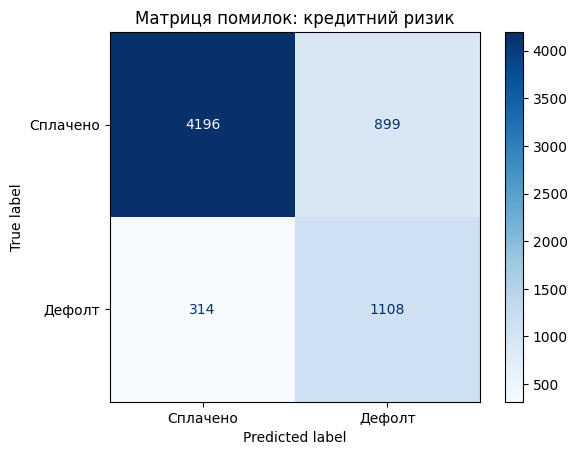

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Матриця помилок (confusion matrix)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплачено', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок: кредитний ризик')
plt.show()

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.814
Precision (Влучність):  0.552
Recall (Повнота):       0.779
F1-score:               0.646


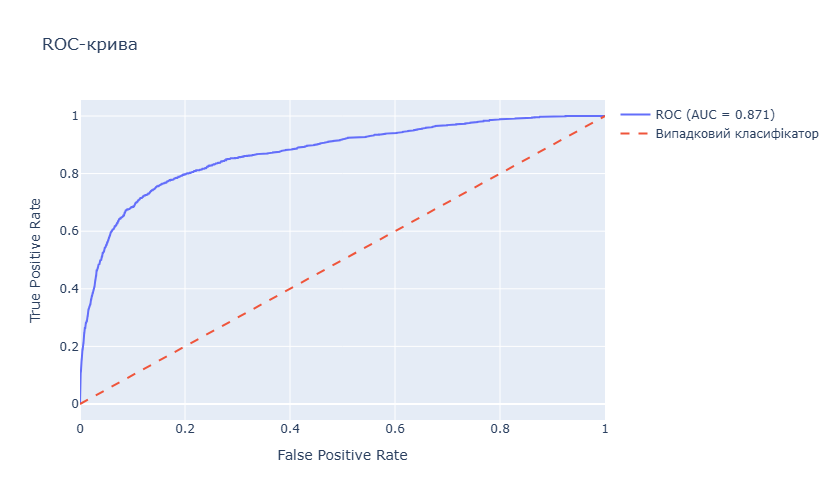

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score

# Обчислюємо ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

# Візуалізація
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

In [73]:
# Отримуємо коефіцієнти моделі
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5,loan_percent_income,1.368675,1.368675
17,loan_grade_D,0.806317,0.806317
3,loan_amnt,-0.652255,0.652255
18,loan_grade_E,0.487904,0.487904
8,person_home_ownership_OWN,-0.434803,0.434803
14,loan_intent_VENTURE,-0.396583,0.396583
9,person_home_ownership_RENT,0.335727,0.335727
19,loan_grade_F,0.286783,0.286783
20,loan_grade_G,0.263944,0.263944
10,loan_intent_EDUCATION,-0.245834,0.245834


**Висновок про якість моделі:**

Модель досить добре справляється з класифікацією, особливо з дефолтами (recall ≈ 0.78).  
Точність у передбаченні дефолтів (precision ≈ 0.55) середня, тобто є частина хибних спрацьовувань.  
Загалом якість можна оцінити як добру, але є можливості для покращення, особливо для зменшення false positives.

**Найважливіші ознаки, що впливають на ймовірність дефолту:**

- Відношення кредиту до доходу (loan_percent_income)  
- Кредитний рейтинг (loan_grade)  
- Тип володіння житлом (person_home_ownership)


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



   threshold  precision    recall        f1
0       0.10   0.260748  0.985232  0.412362
1       0.25   0.359955  0.900141  0.514263
2       0.45   0.513696  0.804501  0.627021
3       0.60   0.628942  0.715190  0.669299
4       0.80   0.767490  0.524613  0.623225


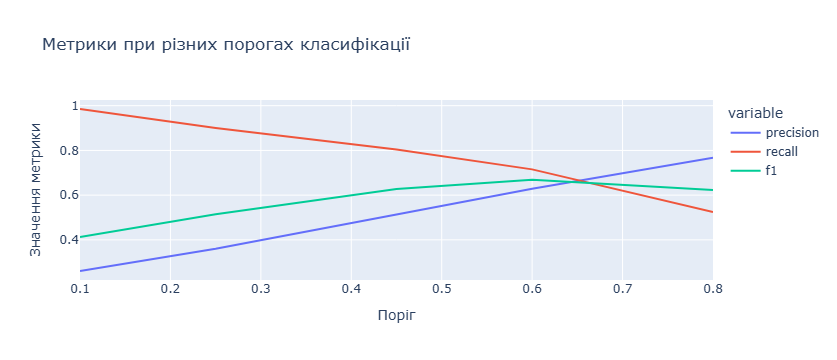

In [77]:
# Аналіз метрик при різних порогах
thresholds = [0.1, 0.25, 0.45, 0.6, 0.8]
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_test_proba >= threshold).astype(int)
    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)
print(metrics_df)

# Візуалізація змін метрик
fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах класифікації',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'}
)
fig.show()


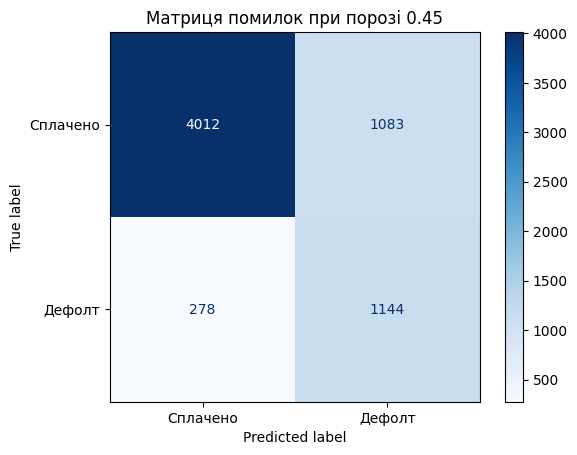

Оптимальний поріг: 0.45
Precision: 0.514
Recall: 0.805
F1-score: 0.627


In [78]:
# Вибір оптимального порогу
optimal_threshold = 0.45
y_pred_opt = (y_test_proba >= optimal_threshold).astype(int)

# Перевірка через матрицю помилок
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплачено', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title(f'Матриця помилок при порозі {optimal_threshold}')
plt.show()

# Висновки
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

print(f"Оптимальний поріг: {optimal_threshold}")
print(f"Precision: {precision_opt:.3f}")
print(f"Recall: {recall_opt:.3f}")
print(f"F1-score: {f1_opt:.3f}")



---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Навчаємо альтернативні моделі
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.867      0.768   0.563  0.649  0.869
1        Decision Tree     0.903      0.982   0.568  0.719  0.874
2        Random Forest     0.932      0.955   0.722  0.822  0.931


**Висновки:**

Найкраща модель – Random Forest:

Найвища точність (Accuracy = 0.932) і AUC (0.931), що означає хорошу здатність моделі відрізняти дефолтні кредити від нормальних.

Найкраще поєднання Recall і Precision (F1 = 0.822) – відмінно для бізнес-задачі, де важливо вчасно виявити потенційний дефолт.

Для бізнес-задачі (упередження дефолтів важливіше, ніж мінімізація хибних тривог) Random Forest – найдоцільніший варіант.
